# Day 9 – Ensemble Learning
### 20-Day ML Revision Planner | Phase: Advanced ML

**Topics covered:**
1. Bagging: Bootstrap Sampling, Independent Base Learners, Aggregation
2. Boosting: AdaBoost, Gradient Boosting, XGBoost, LightGBM, CatBoost
3. Key Ideas: Weak Learners, Learning Rate, Number of Estimators, Tree Depth, Subsampling
4. Core Distinction: Bagging vs Boosting
5. Coding: Train Gradient Boosting / XGBoost and Compare with Random Forest
6. Ensemble Learning Comparison Chart
7. Interview Questions
8. Active Recall Checklist

**Revision rule:** Learn → Close Notes → Recall → Code → Debug → Explain → Interview Question.

---


In [1]:
# Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

try:
    import xgboost as xgb
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False

try:
    import lightgbm as lgb
    LGB_AVAILABLE = True
except ImportError:
    LGB_AVAILABLE = False

try:
    import catboost as cb
    CATBOOST_AVAILABLE = True
except ImportError:
    CATBOOST_AVAILABLE = False

np.set_printoptions(precision=4, suppress=True)
pd.set_option('display.precision', 4)
np.random.seed(42)

print("XGBoost available:", XGB_AVAILABLE)
print("LightGBM available:", LGB_AVAILABLE)
print("CatBoost available:", CATBOOST_AVAILABLE)


XGBoost available: True
LightGBM available: False
CatBoost available: False


## 1. Bagging: Bootstrap Sampling, Independent Base Learners, Aggregation

### What?
**Bagging (Bootstrap AGGregatING)**: train many **independent** base learners (usually decision trees) on different **bootstrap samples** of the training data, then combine their predictions.

- **Bootstrap sampling**: sample with replacement, same size as the original dataset (recall Day 7).
- **Independent base learners**: each model is trained **in parallel**, with no knowledge of the others.
- **Aggregation**: majority **vote** (classification) or **average** (regression) across all learners.

### Why?
Recall from Day 7: averaging many high-variance, decorrelated models reduces overall variance without increasing bias much. **Random Forest is the most famous bagging algorithm** (plus its extra random-feature-selection twist).

### How?
Because each learner is trained independently, bagging is naturally **parallelizable** — a key practical advantage over boosting (below).


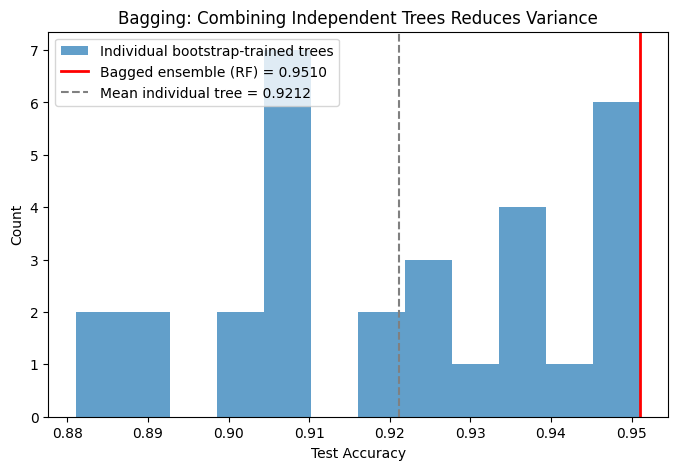

In [2]:
# Recap visualization: bagging reduces variance by averaging independent, diverse trees
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

single_tree_accs = []
n_repeats = 30
for seed in range(n_repeats):
    # Bootstrap sample the training data manually to illustrate the bagging mechanism
    boot_idx = np.random.RandomState(seed).choice(len(X_train), len(X_train), replace=True)
    X_boot, y_boot = X_train.iloc[boot_idx], y_train.iloc[boot_idx]
    tree = DecisionTreeClassifier(max_depth=5, random_state=seed).fit(X_boot, y_boot)
    single_tree_accs.append(accuracy_score(y_test, tree.predict(X_test)))

bagged_rf = RandomForestClassifier(n_estimators=n_repeats, max_depth=5, random_state=42).fit(X_train, y_train)
bagged_acc = accuracy_score(y_test, bagged_rf.predict(X_test))

plt.figure(figsize=(8, 5))
plt.hist(single_tree_accs, bins=12, alpha=0.7, label="Individual bootstrap-trained trees")
plt.axvline(bagged_acc, color='red', linewidth=2, label=f"Bagged ensemble (RF) = {bagged_acc:.4f}")
plt.axvline(np.mean(single_tree_accs), color='gray', linestyle='--',
            label=f"Mean individual tree = {np.mean(single_tree_accs):.4f}")
plt.xlabel("Test Accuracy"); plt.ylabel("Count")
plt.title("Bagging: Combining Independent Trees Reduces Variance")
plt.legend()
plt.show()


## 2. Boosting: AdaBoost, Gradient Boosting, XGBoost, LightGBM, CatBoost

### What?
**Boosting** trains base learners **sequentially**, where each new learner focuses on **correcting the mistakes** of the previous ones. Unlike bagging, the learners are **not independent** — each depends explicitly on the ones before it.

- **AdaBoost (Adaptive Boosting)**: re-weights misclassified samples so the next weak learner focuses more on them; final prediction is a weighted vote of all learners.
- **Gradient Boosting**: each new tree is trained to predict the **residual errors** (or more precisely, the negative gradient of the loss) of the current ensemble — framed as gradient descent *in function space*.
- **XGBoost (Extreme Gradient Boosting)**: a highly optimized, regularized implementation of gradient boosting — faster, with built-in handling of missing values and regularization terms to control overfitting.
- **LightGBM**: uses histogram-based splitting and leaf-wise (rather than level-wise) tree growth for speed on large datasets.
- **CatBoost**: designed with strong native support for categorical features and reduced prediction bias via "ordered boosting."

### Why?
Boosting often achieves **higher accuracy** than bagging on structured/tabular data, because each new model is explicitly targeting the ensemble's current weaknesses rather than just adding independent "votes." This is why gradient-boosted tree variants (XGBoost, LightGBM, CatBoost) dominate tabular-data ML competitions.

### How?
1. Start with a simple model (often just predicting the mean/majority class).
2. Compute residuals/errors.
3. Train a new weak learner to predict those residuals/errors.
4. Add the new learner's predictions (scaled by a **learning rate**) to the ensemble.
5. Repeat for many rounds.


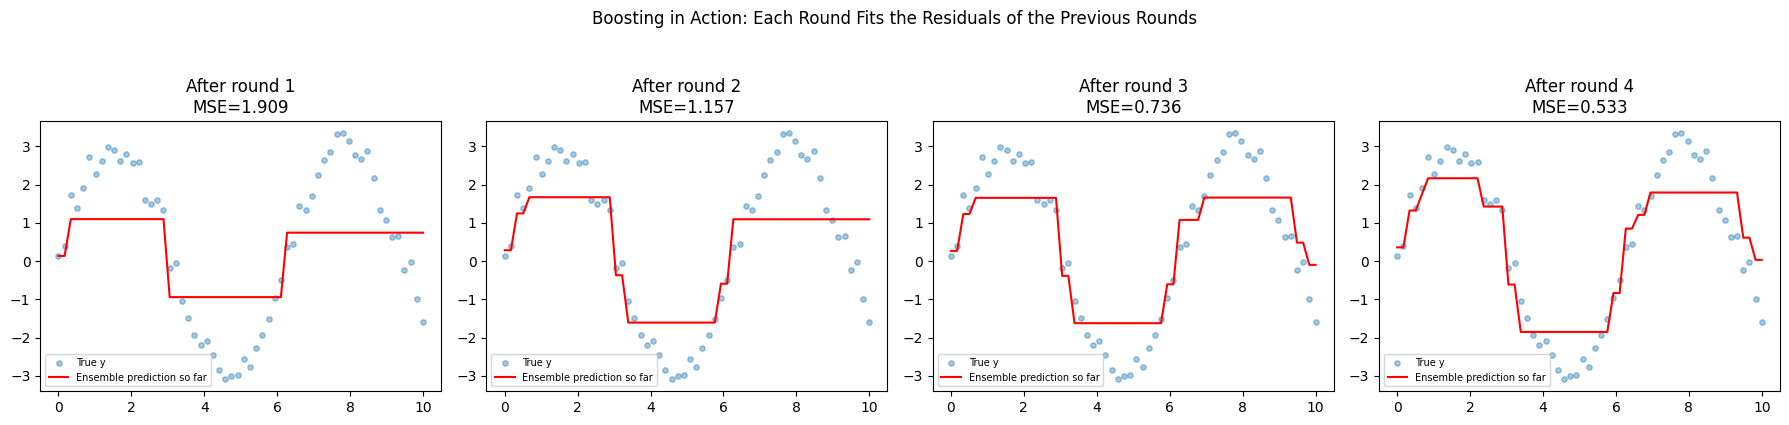

--> Notice the ensemble prediction (red) gets progressively closer to the true signal
    as more rounds are added, each one correcting the remaining error.


In [3]:
# Visualize the core boosting idea: sequentially fitting to residuals (regression illustration)
np.random.seed(5)
x_boost = np.linspace(0, 10, 60).reshape(-1, 1)
y_boost = np.sin(x_boost).ravel() * 3 + np.random.normal(0, 0.3, 60)

from sklearn.tree import DecisionTreeRegressor

learning_rate = 0.5
n_rounds = 4
current_prediction = np.zeros_like(y_boost)
fig, axes = plt.subplots(1, n_rounds, figsize=(18, 4))

for i in range(n_rounds):
    residuals = y_boost - current_prediction
    stump = DecisionTreeRegressor(max_depth=2, random_state=i).fit(x_boost, residuals)
    update = stump.predict(x_boost)
    current_prediction = current_prediction + learning_rate * update

    axes[i].scatter(x_boost, y_boost, alpha=0.4, s=15, label="True y")
    axes[i].plot(x_boost, current_prediction, color='red', label="Ensemble prediction so far")
    axes[i].set_title(f"After round {i+1}\nMSE={np.mean((y_boost - current_prediction)**2):.3f}")
    axes[i].legend(fontsize=7)

plt.suptitle("Boosting in Action: Each Round Fits the Residuals of the Previous Rounds", y=1.05)
plt.tight_layout()
plt.show()
print("--> Notice the ensemble prediction (red) gets progressively closer to the true signal")
print("    as more rounds are added, each one correcting the remaining error.")


## 3. Key Ideas: Weak Learners, Learning Rate, Number of Estimators, Tree Depth, Subsampling

### What?
- **Weak learner**: a model only slightly better than random guessing (classically, very shallow trees / "stumps" — depth 1-3). Boosting combines many weak learners into one strong ensemble.
- **Learning rate ($\eta$ or `learning_rate`)**: shrinks each new learner's contribution, e.g., $F_m(x) = F_{m-1}(x) + \eta \cdot h_m(x)$. Smaller learning rate = more conservative updates, generally needing more estimators but often generalizing better.
- **Number of estimators (`n_estimators`)**: how many sequential rounds/trees to add.
- **Tree depth (`max_depth`)**: complexity of each individual weak learner — kept shallow in boosting (unlike bagging, which can use deeper trees since averaging handles the variance).
- **Subsampling (`subsample`)**: using only a random fraction of data (and/or features) per boosting round — introduces some of bagging's randomness/regularization benefit into boosting (this variant is called **Stochastic Gradient Boosting**).

### Why?
These hyperparameters jointly control the classic **bias-variance trade-off** for boosting:
- Too high a learning rate / too many deep trees → overfits quickly (boosting has NO inherent variance reduction like bagging — it can memorize noise if left unchecked).
- Too low a learning rate with too few estimators → underfits (hasn't had enough rounds to converge).

### How? — The learning-rate/n_estimators trade-off
There's a well-known trade-off: a **smaller learning rate** requires **more estimators** to reach the same training fit, but this combination often generalizes better than fewer estimators with a large learning rate (smaller, more numerous corrective steps vs. a few large, potentially overshooting ones — echoing Day 2's gradient descent learning-rate intuition).


In [4]:
# Demonstrate the learning_rate / n_estimators trade-off on the real dataset
from sklearn.model_selection import cross_val_score

configs = [
    (1.0, 10),
    (0.5, 20),
    (0.1, 100),
    (0.01, 500),
]

print("learning_rate | n_estimators | mean CV accuracy")
for lr, n_est in configs:
    gb = GradientBoostingClassifier(learning_rate=lr, n_estimators=n_est, max_depth=3, random_state=42)
    scores = cross_val_score(gb, X_train, y_train, cv=5)
    print(f"{lr:>13} | {n_est:>12} | {scores.mean():.4f} (+/- {scores.std():.4f})")

print("\n--> A well-chosen SMALL learning rate + MANY estimators often matches or beats a large")
print("    learning rate + few estimators, and tends to generalize more robustly.")


learning_rate | n_estimators | mean CV accuracy
          1.0 |           10 | 0.9318 (+/- 0.0204)


          0.5 |           20 | 0.9437 (+/- 0.0202)


          0.1 |          100 | 0.9507 (+/- 0.0136)


         0.01 |          500 | 0.9460 (+/- 0.0241)

--> A well-chosen SMALL learning rate + MANY estimators often matches or beats a large
    learning rate + few estimators, and tends to generalize more robustly.


## 4. Core Distinction: Bagging vs Boosting

| | Bagging | Boosting |
|---|---|---|
| Training | **Parallel** — learners trained independently | **Sequential** — each learner depends on previous ones |
| Goal | Reduce **variance** | Reduce **bias** (and can reduce variance too, with care) |
| Base learner complexity | Can be deep/complex (e.g., full decision trees) | Usually shallow/weak (stumps, depth 2-4) |
| Data sampling | Bootstrap sampling (with replacement) | Often uses full data, re-weighted or with residual targets; optional subsampling |
| Overfitting risk | Lower — averaging naturally regularizes | Higher — can overfit if `n_estimators`/`learning_rate` not controlled |
| Speed | Faster (parallelizable) | Slower (inherently sequential, though implementations optimize this) |
| Canonical example | Random Forest | AdaBoost, Gradient Boosting, XGBoost, LightGBM, CatBoost |

**Core distinction (from the planner):** Bagging trains models independently; boosting builds models sequentially to correct previous errors.


In [5]:
# Side-by-side train/test accuracy: Bagging (Random Forest) vs Boosting (Gradient Boosting)
rf_compare = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42).fit(X_train, y_train)
gb_compare = GradientBoostingClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42).fit(X_train, y_train)

for name, model in [("Random Forest (Bagging)", rf_compare), ("Gradient Boosting (Boosting)", gb_compare)]:
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))
    print(f"{name}: Train={train_acc:.4f} | Test={test_acc:.4f} | Gap={train_acc - test_acc:.4f}")


Random Forest (Bagging): Train=0.9930 | Test=0.9510 | Gap=0.0419
Gradient Boosting (Boosting): Train=1.0000 | Test=0.9580 | Gap=0.0420


## 5. Coding Practice — Train Gradient Boosting / XGBoost and Compare with Random Forest


In [6]:
# Train Random Forest, sklearn's GradientBoostingClassifier, AdaBoost, and XGBoost (if available)
models = {
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=200, learning_rate=0.5, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, max_depth=3, learning_rate=0.1, random_state=42),
}

if XGB_AVAILABLE:
    models['XGBoost'] = xgb.XGBClassifier(
        n_estimators=200, max_depth=3, learning_rate=0.1,
        use_label_encoder=False, eval_metric='logloss', random_state=42
    )

predictions = {}
probabilities = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions[name] = model.predict(X_test)
    probabilities[name] = model.predict_proba(X_test)[:, 1]

print(f"Trained {len(models)} models: {list(models.keys())}")


Trained 4 models: ['Random Forest', 'AdaBoost', 'Gradient Boosting', 'XGBoost']


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [04:45:02] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [7]:
# Build the ensemble comparison table
comparison_results = []
for name in models:
    y_pred = predictions[name]
    y_prob = probabilities[name]
    comparison_results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    })

comparison_df = pd.DataFrame(comparison_results).set_index('Model')
print(comparison_df.round(4))


                   Accuracy  Precision  Recall  F1-score  ROC-AUC
Model                                                            
Random Forest         0.958     0.9565  0.9778    0.9670   0.9937
AdaBoost              0.958     0.9565  0.9778    0.9670   0.9878
Gradient Boosting     0.958     0.9468  0.9889    0.9674   0.9950
XGBoost               0.965     0.9570  0.9889    0.9727   0.9952


## 6. Ensemble Learning Comparison Chart (Daily Output)


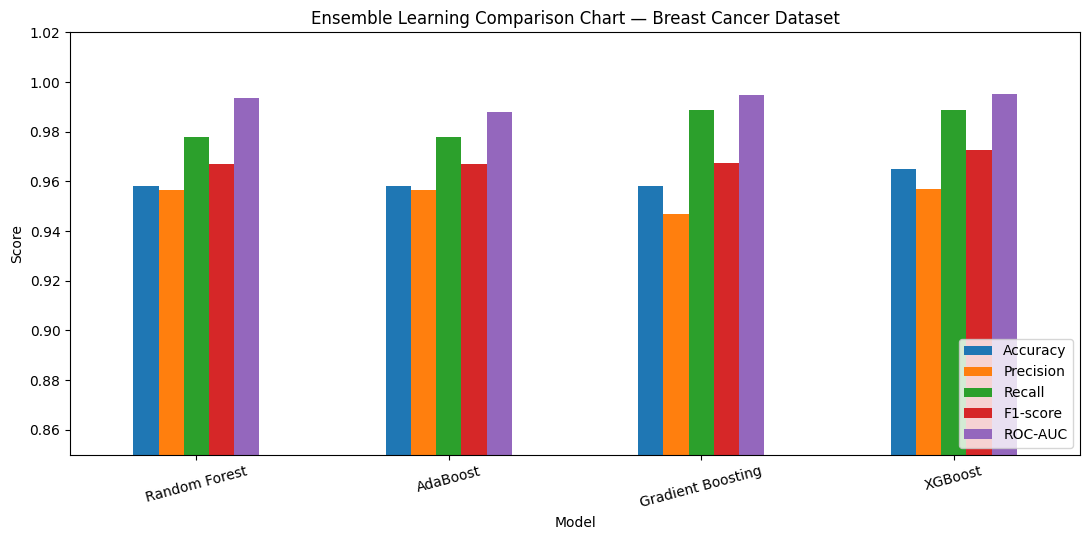

In [8]:
# Required daily output: Ensemble Learning Comparison Chart
comparison_df.plot(kind='bar', figsize=(11, 5.5), ylim=(0.85, 1.02))
plt.title("Ensemble Learning Comparison Chart — Breast Cancer Dataset")
plt.ylabel("Score")
plt.xticks(rotation=15)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


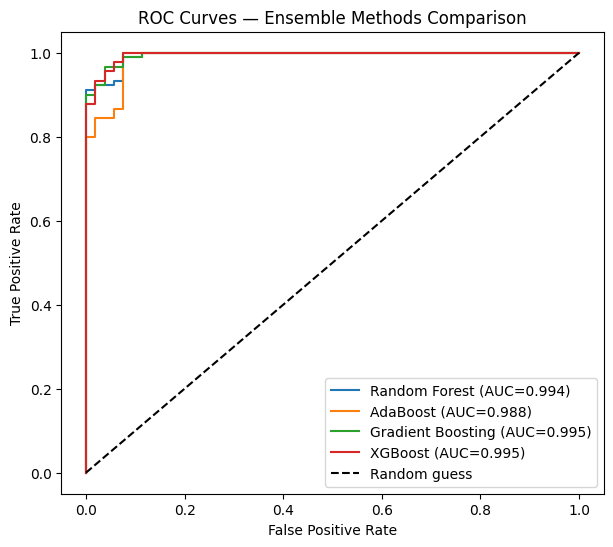

In [9]:
# ROC curves for all ensemble models
plt.figure(figsize=(7, 6))
for name in models:
    fpr, tpr, _ = roc_curve(y_test, probabilities[name])
    auc = roc_auc_score(y_test, probabilities[name])
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
plt.plot([0, 1], [0, 1], 'k--', label="Random guess")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Ensemble Methods Comparison")
plt.legend()
plt.show()


                   Training Time (s)
Model                               
Random Forest                 0.2789
AdaBoost                      0.4489
Gradient Boosting             0.6300
XGBoost                       0.0853


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [04:45:04] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


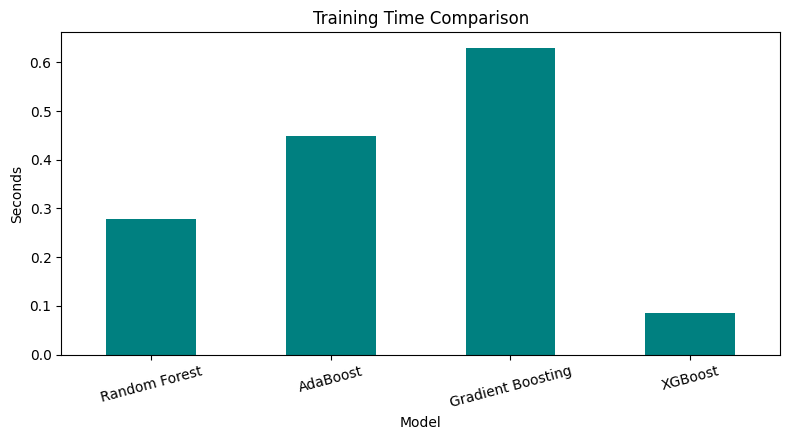

In [10]:
# Training time comparison — a practical consideration alongside accuracy
import time

timing_results = []
for name, model in models.items():
    start = time.time()
    model.fit(X_train, y_train)
    elapsed = time.time() - start
    timing_results.append({'Model': name, 'Training Time (s)': elapsed})

timing_df = pd.DataFrame(timing_results).set_index('Model')
print(timing_df.round(4))

timing_df.plot(kind='bar', figsize=(8, 4.5), legend=False, color='teal')
plt.title("Training Time Comparison")
plt.ylabel("Seconds")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


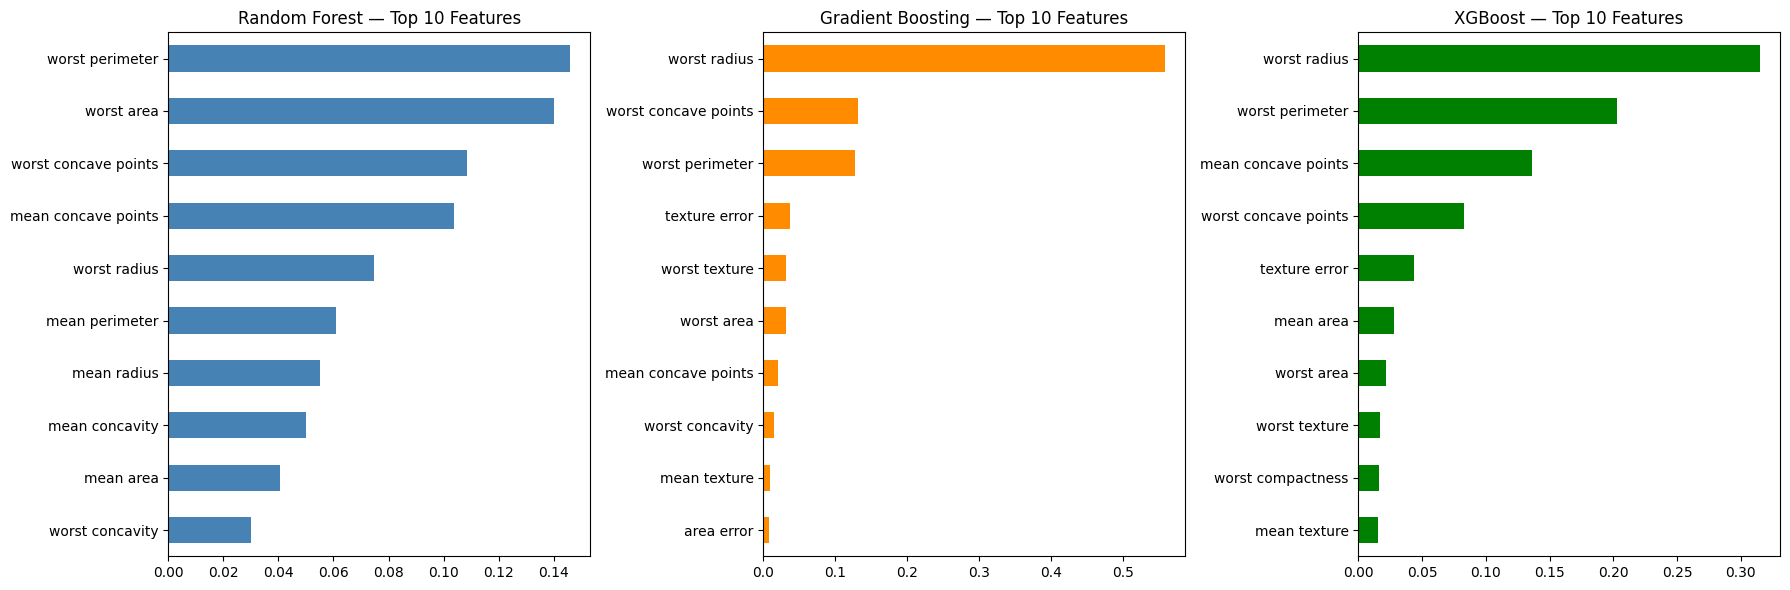

--> Different ensemble methods often agree on the MOST important features, even though
    they arrive at the ensemble in fundamentally different ways (parallel vs sequential).


In [11]:
# Feature importance comparison: Random Forest vs Gradient Boosting (and XGBoost if available)
fig, axes = plt.subplots(1, 2 + int(XGB_AVAILABLE), figsize=(6 * (2 + int(XGB_AVAILABLE)), 6))

rf_importances = pd.Series(models['Random Forest'].feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
gb_importances = pd.Series(models['Gradient Boosting'].feature_importances_, index=X.columns).sort_values(ascending=False).head(10)

rf_importances.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].invert_yaxis(); axes[0].set_title("Random Forest — Top 10 Features")

gb_importances.plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].invert_yaxis(); axes[1].set_title("Gradient Boosting — Top 10 Features")

if XGB_AVAILABLE:
    xgb_importances = pd.Series(models['XGBoost'].feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
    xgb_importances.plot(kind='barh', ax=axes[2], color='green')
    axes[2].invert_yaxis(); axes[2].set_title("XGBoost — Top 10 Features")

plt.tight_layout()
plt.show()
print("--> Different ensemble methods often agree on the MOST important features, even though")
print("    they arrive at the ensemble in fundamentally different ways (parallel vs sequential).")


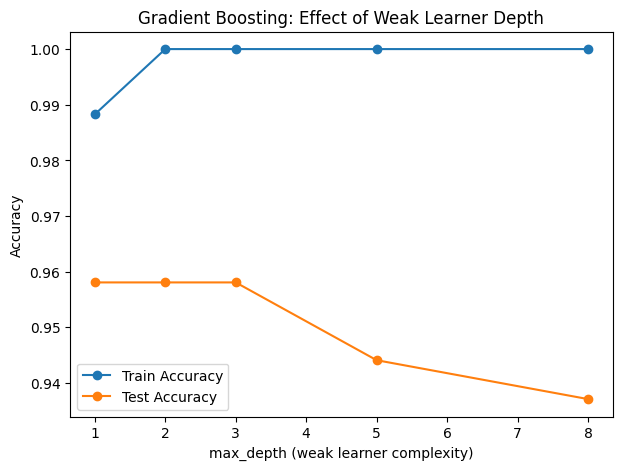

--> Unlike Random Forest (which tolerates deep trees fine due to averaging), Gradient Boosting
    overfits much faster as max_depth increases -- confirming why boosting favors SHALLOW
    weak learners (depth 2-4 is a very common default).


In [12]:
# Debug/tuning exercise: effect of max_depth (weak learner strength) on Gradient Boosting overfitting
depths_gb = [1, 2, 3, 5, 8]
train_accs_gb, test_accs_gb = [], []

for d in depths_gb:
    gb_d = GradientBoostingClassifier(n_estimators=100, max_depth=d, learning_rate=0.1, random_state=42)
    gb_d.fit(X_train, y_train)
    train_accs_gb.append(accuracy_score(y_train, gb_d.predict(X_train)))
    test_accs_gb.append(accuracy_score(y_test, gb_d.predict(X_test)))

plt.figure(figsize=(7, 5))
plt.plot(depths_gb, train_accs_gb, marker='o', label="Train Accuracy")
plt.plot(depths_gb, test_accs_gb, marker='o', label="Test Accuracy")
plt.xlabel("max_depth (weak learner complexity)"); plt.ylabel("Accuracy")
plt.title("Gradient Boosting: Effect of Weak Learner Depth")
plt.legend()
plt.show()

print("--> Unlike Random Forest (which tolerates deep trees fine due to averaging), Gradient Boosting")
print("    overfits much faster as max_depth increases -- confirming why boosting favors SHALLOW")
print("    weak learners (depth 2-4 is a very common default).")


## ML Connection Recap

| Concept | Connects to |
|---|---|
| Bootstrap sampling in bagging | Day 7's Random Forest bootstrap mechanism |
| Boosting as sequential residual-fitting | Day 2's gradient descent (gradient boosting = "gradient descent in function space") |
| Learning rate trade-off | Day 2's learning-rate intuition (small steps, more of them, often generalize better) |
| Shallow weak learners in boosting | Day 7's tree depth / overfitting discussion, applied in reverse (boosting needs shallow trees, bagging tolerates deep ones) |
| Feature importance | Day 7's Random Forest feature importance, now compared across ensemble families |


## 7. Interview Questions — Practice Aloud (Close Your Notes!)

1. **What's the core difference between bagging and boosting?**
   *Hint: bagging trains independent models in parallel to reduce variance; boosting trains models sequentially, each correcting previous errors, primarily reducing bias.*

2. **Why does boosting typically use shallow trees ("weak learners") while bagging (Random Forest) can use deeper trees?**
   *Hint: boosting builds complexity through many sequential corrections — deep individual learners would overfit fast; bagging's averaging already controls variance, so individual trees can be more expressive.*

3. **Explain the role of the learning rate in gradient boosting.**
   *Hint: shrinks each new learner's contribution; smaller learning rate + more estimators often generalizes better than the reverse, similar to Day 2's gradient descent step-size intuition.*

4. **How does XGBoost differ from plain Gradient Boosting?**
   *Hint: adds regularization terms, optimized/parallelized computation, built-in missing-value handling, and other engineering improvements for speed and accuracy.*

5. **Why is boosting generally harder to parallelize than bagging?**
   *Hint: each boosting round depends on the residuals/errors of the previous round — inherently sequential, unlike bagging's independent learners.*

6. **(Bonus) What is subsampling (stochastic gradient boosting), and why might it help?**
   *Hint: using a random subset of data/features per boosting round injects some of bagging's variance-reduction benefit into boosting, acting as a regularizer.*

7. **(Bonus) When might you prefer Random Forest over XGBoost, or vice versa?**
   *Hint: Random Forest is simpler, more robust to hyperparameter choices, less prone to overfitting out of the box; XGBoost/boosted methods often achieve higher accuracy on structured/tabular data but need more careful tuning (learning rate, depth, estimators) to avoid overfitting.*


## 8. Active Recall & Daily Output

**Self-check (mark ✔ only if you can do this without notes):**
- [ ] Explain bagging (bootstrap sampling, independent learners, aggregation) from memory.
- [ ] Explain boosting (sequential learners, correcting previous errors) from memory.
- [ ] Name the core distinction: bagging reduces variance via parallel independent models; boosting reduces bias via sequential error-correction.
- [ ] List AdaBoost, Gradient Boosting, XGBoost, LightGBM, and CatBoost, and give one distinguishing feature of each.
- [ ] Explain the role of learning rate, n_estimators, tree depth, and subsampling in boosting.
- [ ] Explain why boosting favors shallow weak learners while bagging tolerates deeper trees.
- [ ] Train Gradient Boosting/XGBoost and Random Forest on a dataset and compare their metrics from memory.

### 📌 Daily Output (per the planner)
An **Ensemble Learning Comparison Chart** (Section 6) comparing Random Forest, AdaBoost, Gradient Boosting, and XGBoost (when available) on Accuracy, Precision, Recall, F1-score, and ROC-AUC — plus ROC curves, training-time comparison, feature-importance comparison across ensemble families, and a max_depth overfitting analysis for boosting (Section 5).

Close this notebook and re-explain, from memory, why Gradient Boosting's test accuracy degrades faster than Random Forest's as tree depth increases — that's the real test of Day 9 mastery.
